# Kernel Methods Assignment
ECE 645 – Machine Learning  
University of Hawaiʻi  

Group Members:
- Name 1
- Name 2
- Name 3
- Name 4
- Name 5
- Name 6

---

This notebook contains the code and theoretical explanations for the **Kernel Methods assignment**.

Table of Contents:

1. Distance from a point to a plane (Proof)
2. Cross-validated generalization error estimate for SVC
3. Topic classification using Support Vector Classifiers
4. Credit risk prediction using kernel SVMs

In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns # better data visualization

from sklearn import svm
from sklearn.svm import SVC
from sklearn.datasets import fetch_20newsgroups_vectorized

from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

---
# Problem 1: 
## Distance of a Point to a Plane

Show that the **distance of a point from a plane** is

$$
\frac{w^T x - b}{\|w\|}
$$

where, as usual, $\|w\|$ is the length of the vector $w$.

This needs to be written as a **proper proof**.

## Proof

Define a plane by the equation:

$$
\mathbf{w}^T \mathbf{x} - b = 0
$$

where $\mathbf{w}$ is a vector normal to the plane.

1. **Choose a point on the plane.**  
   Let $\mathbf{x}$ be an arbitrary point in $\mathbb{R}^n$. Choose a point $\mathbf{w_0}$ that lies on the plane, so that

   $$
   \mathbf{w}^T \mathbf{x_0} = b.
   $$

2. **Define the displacement vector.**  
   Define the vector from the point on the plane $\mathbf{x_0}$ to the point $\mathbf{x}$ as

   $$
   \mathbf{e} = \mathbf{x} - \mathbf{x_0}.
   $$

3. **Use orthogonality of the normal vector.**  
   Since $\mathbf{w}$ is perpendicular to the plane, the shortest distance from $\mathbf{x}$ to the plane occurs along the direction of $\mathbf{w}$. Thus the distance is the magnitude of the component of $\mathbf{e}$ in the direction of $\mathbf{w}$.

4. **Normalize the normal vector  $\mathbf{w}$**  
   Let the unit vector in the direction of $\mathbf{w}$ be

   $$
   \hat{\mathbf{w}} = \frac{\mathbf{w}}{\|\mathbf{w}\|}.
   $$

5. **Compute the projection.**  
   The distance from $\mathbf{w}$ to the plane is the magnitude of the projection of $\mathbf{e}$ onto $\hat{\mathbf{w}}$:

   $$
   d = |\hat{\mathbf{w}}^T \mathbf{e}|.
   $$

6. **Substitute the definitions.**  
   Substituting $\mathbf{e} = \mathbf{x} - \mathbf{x_0}$ and $\hat{\mathbf{w}} = \frac{\mathbf{w}}{\|\mathbf{w}\|}$,

   $$
   d = \left|\frac{\mathbf{w}^T (\mathbf{x} - \mathbf{x_0})}{\|\mathbf{w}\|}\right|.
   $$

7. **Distribute the dot product.**

   $$
   d = \left|\frac{\mathbf{w}^T \mathbf{x} - \mathbf{w}^T \mathbf{x_0}}{\|\mathbf{w}\|}\right|.
   $$

8. **Use the plane condition.**  
   Since $\mathbf{x_0}$ lies on the plane, $\mathbf{w}^T \mathbf{x_0} = b$, giving

   $$
   d = \frac{|\mathbf{w}^T \mathbf{x} - b|}{\|\mathbf{w}\|}.
   $$

Therefore, the distance from any point $\mathbf{x}$ to the plane $\mathbf{w}^T \mathbf{x} - b = 0$ is

$$
\boxed{d = \frac{|\mathbf{w}^T \mathbf{x} - b|}{\|\mathbf{w}\|}}
$$

---
# Problem 2: 
## Cross-validated Estimate of Generalization Error

Consider training data

$$
(x_1, y_1), \dots, (x_n, y_n)
$$

Suppose the SVC produces **k support vectors**.

We want to show that the **leave-one-out cross-validation estimate of generalization error** is

$$
\frac{k}{n}
$$

## Proof



---
# Problem 3: 
## Topic Classification with Support Vector Classifiers

In this problem we use the **20 Newsgroups dataset** from `scikit-learn` to build topic classifiers using **Support Vector Classifiers (SVC)** with different kernels.

The dataset contains text documents grouped into **20 different discussion topics**. The goal is to train a classifier that can correctly predict the topic of each document.

We will compare the performance of SVC models using the following kernels:

- **Linear Kernel**
- **Radial Basis Function (RBF) Kernel**
- **Matern Kernel**

For each model, hyperparameters will be optimized using **GridSearchCV**.



## Tasks

1. Compare performance on a **held-out validation set** across the three kernels and discuss why the results look the way they do.

2. For each kernel, identify:
   - **Support vectors**
   - **Misclassified training samples**
   - **Vectors lying directly on the margin**

3. Compare the **validation performance** with the **generalization error estimate from Problem 2**.

4. Investigate how to **assign probabilities to class labels** and justify why this approach is reasonable.



## Workflow

The workflow for this problem is:

1. Load the **vectorized 20 Newsgroups dataset**
2. Split the data into **training and validation sets**
3. Train **SVC models with different kernels**
4. Perform **hyperparameter optimization**
5. Evaluate performance on the validation set
6. Analyze **support vectors and classification behavior**

### Load newsgroups dataset

In [28]:
# Load the 20 newsgroups dataset (vectorized)

news_dataset = fetch_20newsgroups_vectorized()

X = news_dataset.data
y = news_dataset.target


### Train Validation Test Split

In [29]:
TRAIN_TEST_RATIO = 0.2
TRAIN_VALIDATE_RATIO = 0.15
# split into training and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TRAIN_TEST_RATIO,
    random_state=42
    )

# Further split the training set into a training set and validation set
X_train, X_validate, y_train, y_validate = train_test_split(
    X_train_full, 
    y_train_full, 
    test_size=TRAIN_VALIDATE_RATIO,
    random_state=42
    )


## Cross validation

In [30]:
classes = np.unique(y_train)

ovr = OneVsRestClassifier(SVC())

hyperparam_grid = {
    "estimator__C" : [0.1, 1,10],
    "estimator__kernel" : ["linear"],

}

cv = StratifiedKFold(
    n_splits=5, 
    shuffle=True, 
    random_state=42
    )

grid = GridSearchCV(
    estimator=ovr,
    param_grid=hyperparam_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=3

)

grid.fit(X_train, y_train)



Fitting 5 folds for each of 3 candidates, totalling 15 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",OneVsRestClas...timator=SVC())
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__C': [0.1, 1, ...], 'estimator__kernel': ['linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [ ]:
print(f"best parameters: {grid.best_params_}")
print(f"best CV f1_macro: {grid.best_score_:.4f}")
best_ovr = grid.best_estimator_
for c, est in zip(best_ovr.classes_, best_ovr.estimators_):
    print(f"class {c}: {len(est.support_)} support vectors")

unique_sv = np.unique(np.concatenate([est.support_ for est in best_ovr.estimators_]))
print(f"Unique support vectors: {len(unique_sv)}")


NameError: name 'grid' is not defined

In [32]:

selected_classes = np.array(range(20))   

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

linear_param_grid = {
    "C": [0.1,1,10],
    "kernel": ["linear"],
}

linear_models = {}
for c in selected_classes:
    y_bin = (y_train == c).astype(int)   # 1 = class c, 0 = all other classes
    linear_grid = GridSearchCV(
        SVC(),           
        param_grid=linear_param_grid,
        scoring="f1",
        cv=cv,
        verbose=3,
        n_jobs=-1
    )
    linear_grid.fit(X_train, y_bin)
    linear_models[c] = linear_grid.best_estimator_
    print(f"class {c} best: {linear_grid.best_params_}")
    print(f"class {c} # of support vectors: {len(linear_grid.best_estimator_.support_)}")
    print(f"class {c}: score={linear_grid.best_score_:.4f}")




Fitting 5 folds for each of 3 candidates, totalling 15 fits
class 0 best: {'C': 10, 'kernel': 'linear'}
class 0 # of support vectors: 924
class 0: score=0.8670
Fitting 5 folds for each of 3 candidates, totalling 15 fits
class 1 best: {'C': 10, 'kernel': 'linear'}
class 1 # of support vectors: 1370
class 1: score=0.7562
Fitting 5 folds for each of 3 candidates, totalling 15 fits
class 2 best: {'C': 10, 'kernel': 'linear'}
class 2 # of support vectors: 1169
class 2: score=0.7731
Fitting 5 folds for each of 3 candidates, totalling 15 fits
class 3 best: {'C': 10, 'kernel': 'linear'}
class 3 # of support vectors: 1360
class 3: score=0.6705
Fitting 5 folds for each of 3 candidates, totalling 15 fits
class 4 best: {'C': 10, 'kernel': 'linear'}
class 4 # of support vectors: 1269
class 4: score=0.7802
Fitting 5 folds for each of 3 candidates, totalling 15 fits
class 5 best: {'C': 10, 'kernel': 'linear'}
class 5 # of support vectors: 1249
class 5: score=0.8304
Fitting 5 folds for each of 3 candi

### RBF Tuning

In [33]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
import numpy as np

# same class split idea (change [:5] to all classes if needed)
classes = np.unique(y_train)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RBF-only CV grid
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 1e-2, 1e-3, 1e-4],
    "kernel": ["rbf"],
}

rbf_models = {}
rbf_best_params = {}

for c in classes:
    y_bin = (y_train == c).astype(int)  # class c vs rest
    rbf_gs = GridSearchCV(
        estimator=SVC(probability=False),   # useful for AUC/probability-based comparison
        param_grid=param_grid,
        scoring="f1",                 # binary AUC for each OvR model
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    rbf_gs.fit(X_train, y_bin)
    rbf_models[c] = rbf_gs.best_estimator_
    rbf_best_params[c] = rbf_gs.best_params_
    print(f"class {c}: {rbf_gs.best_params_}, f1_score={rbf_gs.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
class 0: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}, f1_score=0.8146
Fitting 5 folds for each of 16 candidates, totalling 80 fits
class 1: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}, f1_score=0.6701
Fitting 5 folds for each of 16 candidates, totalling 80 fits
class 2: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}, f1_score=0.7344
Fitting 5 folds for each of 16 candidates, totalling 80 fits
class 3: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}, f1_score=0.5880
Fitting 5 folds for each of 16 candidates, totalling 80 fits
class 4: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}, f1_score=0.7200
Fitting 5 folds for each of 16 candidates, totalling 80 fits
class 5: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}, f1_score=0.7732
Fitting 5 folds for each of 16 candidates, totalling 80 fits
class 6: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}, f1_score=0.7757
Fitting 5 folds for each of 16 candidates, totalling 80 fits
class 7: {'C': 100, 'gamma'

### Matern Tuning (predefined split + subset)
This uses a custom precomputed Matern kernel with OvR SVC. To keep runtime reasonable, it runs on stratified subsets of train/validation.

In [34]:
from scipy.special import kv, gamma
from sklearn.metrics import f1_score
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import StratifiedShuffleSplit


def matern_from_dists(dists, nu=1.5):
    if nu == 0.5:
        return np.exp(-dists)
    if nu == 1.5:
        sqrt3 = np.sqrt(3.0)
        return (1.0 + sqrt3 * dists) * np.exp(-sqrt3 * dists)
    if nu == 2.5:
        sqrt5 = np.sqrt(5.0)
        return (1.0 + sqrt5 * dists + (5.0 / 3.0) * (dists ** 2)) * np.exp(-sqrt5 * dists)

    d = np.maximum(dists, 1e-12)
    scaled = np.sqrt(2.0 * nu) * d
    coef = (2.0 ** (1.0 - nu)) / gamma(nu)
    K = coef * (scaled ** nu) * kv(nu, scaled)
    K[dists == 0.0] = 1.0
    return K


train_subset_size = min(1500, X_train.shape[0])
val_subset_size = min(600, X_validate.shape[0])

train_splitter = StratifiedShuffleSplit(n_splits=1, train_size=train_subset_size, random_state=42)
val_splitter = StratifiedShuffleSplit(n_splits=1, train_size=val_subset_size, random_state=42)

train_idx, _ = next(train_splitter.split(X_train, y_train))
val_idx, _ = next(val_splitter.split(X_validate, y_validate))

X_train_sub = X_train[train_idx]
y_train_sub = np.asarray(y_train)[train_idx]
X_val_sub = X_validate[val_idx]
y_val_sub = np.asarray(y_validate)[val_idx]

print(f"Matern subset sizes -> train={X_train_sub.shape}, val={X_val_sub.shape}")

nu_grid = [0.5, 1.5, 2.5]
length_scale_grid = [0.5, 1.0, 2.0]
C_grid = [0.1, 1, 10]

matern_results = []

for length_scale in length_scale_grid:
    d_train = pairwise_distances(X_train_sub, X_train_sub, metric="euclidean") / length_scale
    d_val = pairwise_distances(X_val_sub, X_train_sub, metric="euclidean") / length_scale

    for nu in nu_grid:
        K_train = matern_from_dists(d_train, nu=nu)
        K_val = matern_from_dists(d_val, nu=nu)

        for C in C_grid:
            model = OneVsRestClassifier(SVC(kernel="precomputed", C=C, random_state=42))
            model.fit(K_train, y_train_sub)

            y_val_pred = model.predict(K_val)
            matern_results.append(
                {
                    "nu": nu,
                    "length_scale": length_scale,
                    "C": C,
                    "val_accuracy": accuracy_score(y_val_sub, y_val_pred),
                    "val_macro_f1": f1_score(y_val_sub, y_val_pred, average="macro"),
                }
            )

matern_results_df = (
    pd.DataFrame(matern_results)
    .sort_values(["val_macro_f1", "val_accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(matern_results_df.head(10))
best_matern_cfg = matern_results_df.iloc[0].to_dict()
print("Best Matern config:", best_matern_cfg)


Matern subset sizes -> train=(1500, 130107), val=(600, 130107)


,nu,length_scale,C,val_accuracy,val_macro_f1
0,2.5,2.0,10.0,0.805000,0.795741
1,1.5,2.0,10.0,0.800000,0.792063
2,2.5,1.0,10.0,0.790000,0.783770
3,1.5,1.0,10.0,0.788333,0.781824
4,0.5,2.0,10.0,0.780000,0.770771
5,2.5,2.0,1.0,0.776667,0.765296
6,2.5,1.0,1.0,0.773333,0.765071
7,2.5,1.0,0.1,0.771667,0.763222
8,1.5,2.0,1.0,0.773333,0.763066
9,2.5,2.0,0.1,0.773333,0.762571


Best Matern config: {'nu': 2.5, 'length_scale': 2.0, 'C': 10.0, 'val_accuracy': 0.805, 'val_macro_f1': 0.795740675867695}


### Best Matern model diagnostics
Reports validation metrics, support vectors, misclassified validation samples, and near-margin train samples.

              precision    recall  f1-score   support

           0      0.895     0.630     0.739        27
           1      0.800     0.824     0.812        34
           2      0.750     0.794     0.771        34
           3      0.781     0.694     0.735        36
           4      0.839     0.839     0.839        31
           5      0.865     0.941     0.901        34
           6      0.750     0.833     0.789        36
           7      0.906     0.879     0.892        33
           8      0.774     0.960     0.857        25
           9      0.818     0.844     0.831        32
          10      0.897     0.839     0.867        31
          11      0.906     0.879     0.892        33
          12      0.750     0.652     0.698        23
          13      0.714     0.690     0.702        29
          14      0.926     0.893     0.909        28
          15      0.674     0.829     0.744        35
          16      0.743     0.897     0.812        29
          17      0.926    

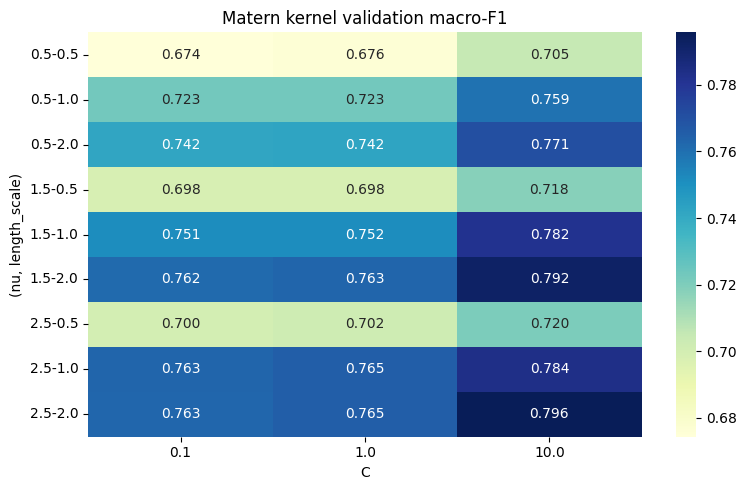

In [35]:
best_nu = float(best_matern_cfg["nu"])
best_length_scale = float(best_matern_cfg["length_scale"])
best_C = float(best_matern_cfg["C"])

d_train_best = pairwise_distances(X_train_sub, X_train_sub, metric="euclidean") / best_length_scale
d_val_best = pairwise_distances(X_val_sub, X_train_sub, metric="euclidean") / best_length_scale
K_train_best = matern_from_dists(d_train_best, nu=best_nu)
K_val_best = matern_from_dists(d_val_best, nu=best_nu)

best_matern_ovr = OneVsRestClassifier(SVC(kernel="precomputed", C=best_C, random_state=42))
best_matern_ovr.fit(K_train_best, y_train_sub)
y_val_pred_best = best_matern_ovr.predict(K_val_best)

print(classification_report(y_val_sub, y_val_pred_best, digits=3))

sv_counts = np.array([len(est.support_) for est in best_matern_ovr.estimators_])
unique_sv = np.unique(np.concatenate([est.support_ for est in best_matern_ovr.estimators_]))
print(f"Support vectors per OvR classifier: mean={sv_counts.mean():.1f}, min={sv_counts.min()}, max={sv_counts.max()}")
print(f"Unique support vectors across OvR classifiers: {len(unique_sv)} / {len(y_train_sub)}")

misclassified_idx = np.where(y_val_pred_best != y_val_sub)[0]
print(f"Misclassified validation samples: {len(misclassified_idx)} / {len(y_val_sub)}")

train_scores = best_matern_ovr.decision_function(K_train_best)
top2 = np.sort(train_scores, axis=1)[:, -2:]
train_margin = top2[:, 1] - top2[:, 0]
margin_threshold = 0.05
near_margin_idx = np.where(train_margin <= margin_threshold)[0]
print(f"Near-margin train samples (margin <= {margin_threshold}): {len(near_margin_idx)} / {len(y_train_sub)}")

pivot = matern_results_df.pivot_table(index=["nu", "length_scale"], columns="C", values="val_macro_f1")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Matern kernel validation macro-F1")
plt.ylabel("(nu, length_scale)")
plt.xlabel("C")
plt.tight_layout()
plt.show()
